In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, recall_score,accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [4]:
df = pd.read_csv("Credit_card_fraud_clean_Data.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print(df.shape)

(284807, 31)


In [7]:
df['Class'].value_counts(normalize=True)


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [8]:
X = df.drop("Class", axis=1)
y = df["Class"]


In [12]:
from imblearn.over_sampling import SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
sm=SMOTE(random_state=42)
X_train_res,y_train_res=sm.fit_resample(X_train,y_train)

print(f"Check classes after balncing:{y_train_res.value_counts(normalize=True)}")


Check classes after balncing:Class
0    0.5
1    0.5
Name: proportion, dtype: float64


In [15]:
rf = RandomForestClassifier(
    n_estimators=200,n_jobs=-1,max_depth=12,random_state=42
)
rf.fit(X_train_res, y_train_res)


,n_estimators,200
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred_rf = rf.predict(X_test)


In [23]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
accuracy_rf=accuracy_score(y_test,y_pred_rf)
print("Confusion Matrix (Random Forest):\n", cm_rf)
print(f"Accuracy_Score:{accuracy_rf}")
print("Recall:", recall_rf)
print(classification_report(y_test, y_pred_rf))


Confusion Matrix (Random Forest):
 [[56805    59]
 [   11    87]]
Accuracy_Score:0.9987711105649381
Recall: 0.8877551020408163
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.89      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_res, y_train_res, n_jobs=-1,cv=skf, scoring='recall')
print(f"Every Fold  Recall Score: {cv_scores}")
print(f"Average Recall Score: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation : {np.std(cv_scores):.4f}")

Every Fold  Recall Score: [0.99096505 0.99087732 0.99001978 0.9906353  0.99162453]
Average Recall Score: 0.9908
Standard Deviation : 0.0005


In [18]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

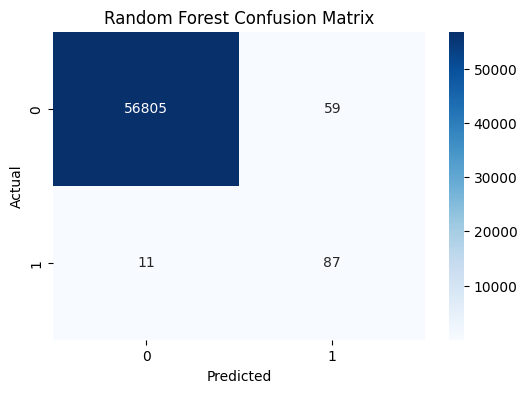

In [19]:
plot_confusion_matrix(cm_rf, "Random Forest Confusion Matrix")


Random Forest Precision: 0.5958904109589042
Random Forest ROC AUC: 0.9897982511800444


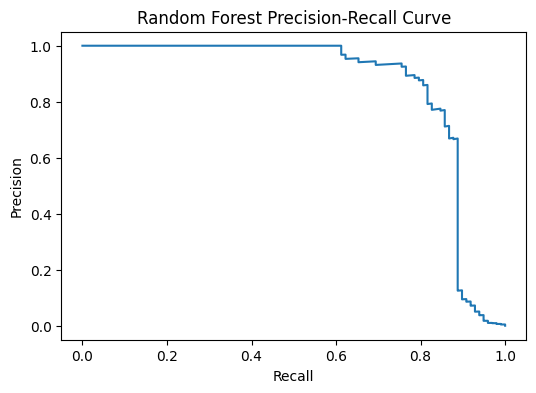

In [36]:
from sklearn.metrics import precision_score, roc_auc_score, precision_recall_curve
# Random Forest Precision, ROC AUC, PR Curve
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))

rf_scores = rf.predict_proba(X_test)[:,1]  # class 1 probabilities
print("Random Forest ROC AUC:", roc_auc_score(y_test, rf_scores))

precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_scores)
plt.figure(figsize=(6,4))
plt.plot(recall_rf, precision_rf, label="Random Forest PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.show()

In [24]:
xgb = XGBClassifier(
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_res, y_train_res)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [25]:
y_pred_xgb = xgb.predict(X_test)


In [34]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
accuracy_xgb=accuracy_score(y_test,y_pred_xgb)
print("Confusion Matrix (XGBoost):\n", cm_xgb)
print("Recall:", recall_xgb)
print("Accuracy:", accuracy_xgb)
print(classification_report(y_test, y_pred_xgb))


Confusion Matrix (XGBoost):
 [[56782    82]
 [   12    86]]
Recall: 0.8775510204081632
Accuracy: 0.9983497770443454
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.88      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.82     56962
weighted avg       1.00      1.00      1.00     56962



In [28]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

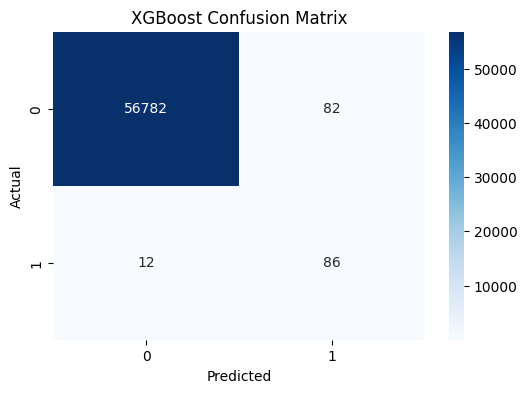

In [35]:
plot_confusion_matrix(cm_xgb, "XGBoost Confusion Matrix")


Precision: 0.5119047619047619
ROC AUC: 0.9874103482135679


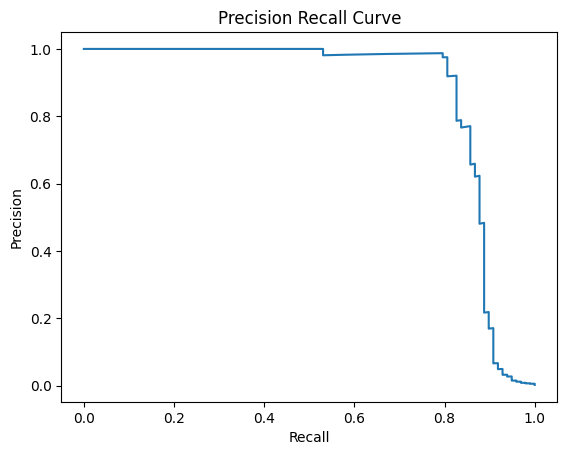

In [37]:

# Precision
print("Precision:", precision_score(y_test, y_pred_xgb))

# ROC AUC
y_scores = xgb.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_scores))

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

In [38]:
import joblib
joblib.dump(rf,"model_rf.pkl")
joblib.dump(xgb,"model_xgb.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']